# **Sam's Club vs Walmart Price Comparison Analysis**
This project uses Python to compare product prices between Sam's Club and Walmart to determine which store offers better value for consumers.

## **1. Import Libraries and Load Dataset**
In this section, the required libraries are imported and the dataset is loaded into Python for analysis.

In [1]:
import pandas as pd
df = pd.read_csv("dataset.csv")
df.head()

,Items,Store,Package size,Unit,Price ($)
0,Chicken breast,Sam's Club,5.69,lbs,16.39
1,Chicken breast,Walmart,1.92,lbs,9.93
2,Pastur raised eggs,Sam's Club,18.00,count,5.87
3,Pastur raised eggs,Walmart,12.00,count,7.46
4,Golden star prime jasmine rice,Sam's Club,8.00,lbs,9.98


## **2. Data Cleaning**
The column names are cleaned by removing spaces and converting text to lowercase. This helps prevent coding errors.

In [3]:
# make sure columns are clean
df.columns = df. columns. str.strip().str.lower()

## **3. Calculate Price Per Unit**
Price per unit is calculated by dividing total price by package size. This allows fair comparison between different product sizes.

In [6]:
# make sure price_per_unit exists
df['price_per_unit' ] = df['price ($)' ] / df['package size' ]

# find cheapest store per item
cheapest = df.loc[df.groupby('items' ) ['price_per_unit']. idxmin() ]

# show result
cheapest[['items', 'store', 'price_per_unit' ]]

,items,store,price_per_unit
40,Aveeno body wash,Sam's Club,0.287576
14,Barilla spagetti,Sam's Club,1.420000
12,Broccoli,Sam's Club,1.635000
24,Built puff protein bars,Sam's Club,1.533846
0,Chicken breast,Sam's Club,2.880492
36,Colgate toothpaste,Sam's Club,0.532667
34,ECOS hypoallergenic detergent,Sam's Club,0.085190
16,Extra virgin olive oil,Sam's Club,0.257059
4,Golden star prime jasmine rice,Sam's Club,1.247500
32,Granulated sugar,Sam's Club,0.658000


## **4. Store Price Comparison**
Products sold in both stores are compared to identify which store offers lower unit prices.

In [7]:
df.columns = df. columns. str.strip() . str. lower()
df['price_per_unit' ] = df ['price ($)' ] / df['package size' ]

valid_items = df.groupby('items' ) ['store' ]. nunique()
valid_items = valid_items[valid_items >= 2].index
df_filtered = df[df['items'].isin(valid_items)]

comparison = df_filtered. pivot_table(
index='items',
columns='store',
values='price_per_unit')

comparison. columns = comparison.columns. str.strip() . str. lower()

comparison['difference' ] = comparison['walmart'] - comparison["sam's club"]

comparison. reset_index()

store,items,sam's club,walmart,difference
0,Aveeno body wash,0.287576,0.393030,0.105455
1,Barilla spagetti,1.420000,1.840000,0.420000
2,Broccoli,1.635000,3.293333,1.658333
3,Built puff protein bars,1.533846,2.245000,0.711154
4,Chicken breast,2.880492,5.171875,2.291383
5,Colgate toothpaste,0.532667,0.703922,0.171255
6,ECOS hypoallergenic detergent,0.085190,0.104364,0.019173
7,Extra virgin olive oil,0.257059,0.442604,0.185545
8,Golden star prime jasmine rice,1.247500,1.985000,0.737500
9,Granulated sugar,0.658000,1.708571,1.050571


## **5. Individual vs Family Spending Analysis**
Total spending is estimated for an individual shopper and a family shopper to compare suitability.

Individual spending:
 store
Sam's Club    25.237347
Walmart       40.074222
Name: individual_cost, dtype: float64

Family spending: 
 store
Sam's Club    126.186735
Walmart       200.371110
Name: family_cost, dtype: float64


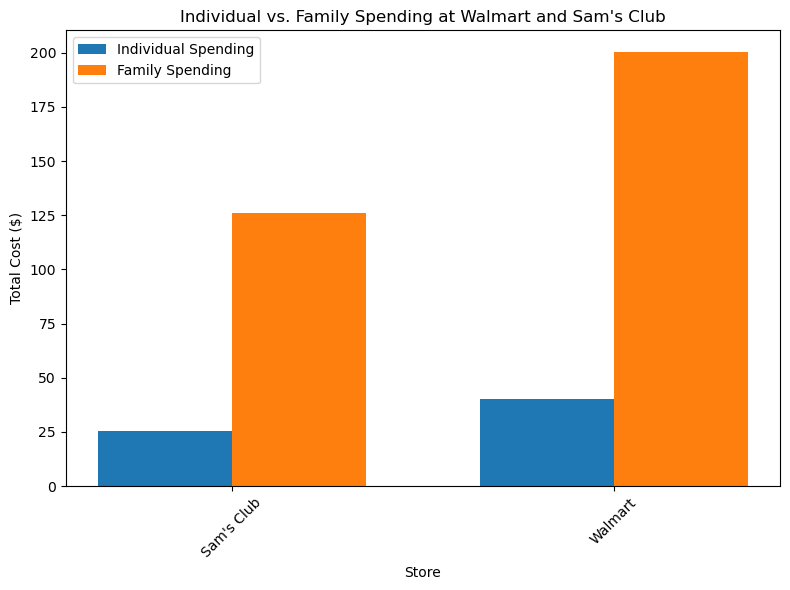

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Make sure columns are clean
df.columns = df.columns.str.strip().str.lower()

# Make sure required column exists
df['price_per_unit'] = df['price ($)'] / df['package size']

# Simulate consumption
individual_qty = 1
family_qty = 5

df['individual_cost'] = df['price_per_unit'] * individual_qty
df['family_cost'] = df['price_per_unit'] * family_qty

# Group by store (Lowercase!)
individual_total = df.groupby('store')['individual_cost'].sum()
family_total = df.groupby('store')['family_cost'].sum()

# Print the results
print("Individual spending:\n", individual_total)
print("\nFamily spending: \n", family_total)

# Create a bar graph to compare individual vs. family spending
plt.figure(figsize=(8, 6))
bar_width = 0.35
index = range(len(individual_total))

# Plot the bars
plt.bar(index, individual_total, bar_width, label='Individual Spending')
plt.bar([i + bar_width for i in index], family_total, bar_width, label='Family Spending')

# Adding labels and title
plt.xlabel('Store')
plt.ylabel('Total Cost ($)')
plt.title('Individual vs. Family Spending at Walmart and Sam\'s Club')
plt.xticks([i + bar_width / 2 for i in index], individual_total.index, rotation=45)
plt.legend()

# Display the plot
plt.tight_layout()
plt.show()

## **6. Membership Fee Impact**
Sam's Club membership fee is added to determine whether savings still remain after additional costs.

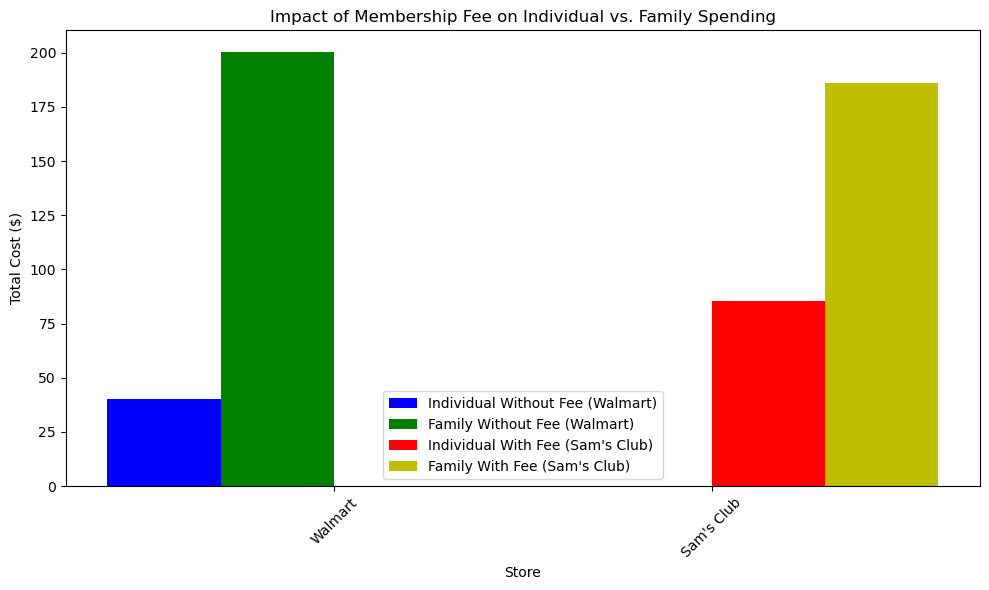

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming the dataframe 'df' is already loaded and cleaned

# Define the membership fee
membership_fee = 60  # annual fee

# Recalculate individual and family costs if not done already
df['individual_cost'] = df['price_per_unit'] * 1  # 1 for individual
df['family_cost'] = df['price_per_unit'] * 5      # 5 for family

# Strip whitespace and make store names lowercase for consistency
df['store'] = df['store'].str.strip().str.lower()

# Grouping and summing the individual and family costs before the membership fee
individual_total = df.groupby('store')['individual_cost'].sum()
family_total = df.groupby('store')['family_cost'].sum()

# Create a copy of the totals to add the membership fee impact for Sam's Club
individual_total_with_fee = individual_total.copy()
family_total_with_fee = family_total.copy()

# Add the membership fee ONLY to Sam's Club
if "sam's club" in individual_total_with_fee.index:
    individual_total_with_fee["sam's club"] += membership_fee
    family_total_with_fee["sam's club"] += membership_fee
else:
    print("Sam's Club is not found in the data. Here's the available stores:", individual_total_with_fee.index)

# Create a DataFrame to organize the data
comparison_data = {
    'Store': ['Walmart', "Sam's Club"],
    'Individual Without Fee': [individual_total.get('walmart', 0), 0],  # Walmart has no fee
    'Family Without Fee': [family_total.get('walmart', 0), 0],          # Walmart has no fee
    'Individual With Fee': [0, individual_total_with_fee.get("sam's club", 0)],  # Sam's Club with fee
    'Family With Fee': [0, family_total_with_fee.get("sam's club", 0)]             # Sam's Club with fee
}

# Create a DataFrame for the final comparison
comparison_df = pd.DataFrame(comparison_data)

# Plot the grouped bar chart
fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.3
index = range(len(comparison_df))

# Plot the bars
ax.bar(index, comparison_df['Individual Without Fee'], bar_width, label='Individual Without Fee (Walmart)', color='b')
ax.bar([i + bar_width for i in index], comparison_df['Family Without Fee'], bar_width, label='Family Without Fee (Walmart)', color='g')
ax.bar([i + bar_width * 2 for i in index], comparison_df['Individual With Fee'], bar_width, label="Individual With Fee (Sam's Club)", color='r')
ax.bar([i + bar_width * 3 for i in index], comparison_df['Family With Fee'], bar_width, label="Family With Fee (Sam's Club)", color='y')

# Adding labels and title
ax.set_xlabel('Store')
ax.set_ylabel('Total Cost ($)')
ax.set_title('Impact of Membership Fee on Individual vs. Family Spending')
ax.set_xticks([i + bar_width * 1.5 for i in index])
ax.set_xticklabels(comparison_df['Store'], rotation=45)

# Display the legend
ax.legend()

# Adjust layout for better spacing
plt.tight_layout()

# Display the plot
plt.show()

## **7. Savings Visualisation**
A bar chart is used to show percentage savings from buying products at Sam's Club instead of Walmart.

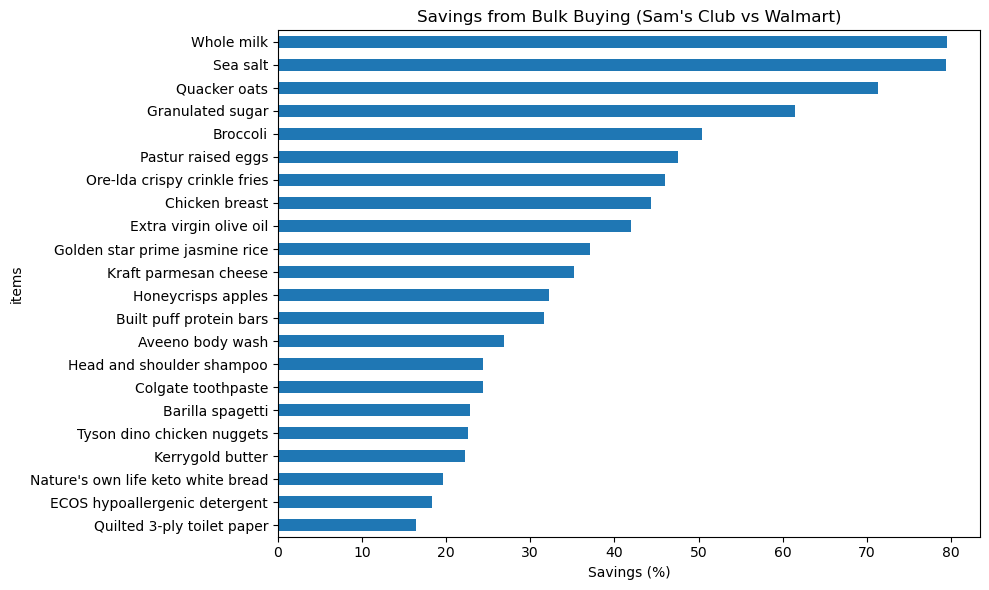

In [19]:
import matplotlib.pyplot as plt

# make sure savings exists
comparison['savings_%' ] = (
(comparison['walmart'] - comparison["sam's club"]) / comparison['walmart' ]
) * 100

# sort for nicer graph
comparison_sorted = comparison. sort_values('savings_%' )

# horizontal bar chart (best for readability)
comparison_sorted['savings_%' ].plot(kind='barh', figsize=(10,6))

plt.xlabel("Savings (%)")
plt.title("Savings from Bulk Buying (Sam's Club vs Walmart)")

plt.tight_layout()
plt.show()

## **8. Conclusion**
- Walmart is more suitable for smaller or occasional purchases.
- Sam's Club offers better long-term value for families and bulk buyers.
- Python helped automate calculations and support data-driven.

In [21]:
comparison['savings_%' ] = (
(comparison['walmart' ] - comparison["sam's club"]) / comparison['walmart' ]
) * 100

comparison

store,sam's club,walmart,difference,savings_%
items,,,,
Aveeno body wash,0.287576,0.393030,0.105455,26.831149
Barilla spagetti,1.420000,1.840000,0.420000,22.826087
Broccoli,1.635000,3.293333,1.658333,50.354251
Built puff protein bars,1.533846,2.245000,0.711154,31.677231
Chicken breast,2.880492,5.171875,2.291383,44.304685
Colgate toothpaste,0.532667,0.703922,0.171255,24.328691
ECOS hypoallergenic detergent,0.085190,0.104364,0.019173,18.371495
Extra virgin olive oil,0.257059,0.442604,0.185545,41.921202
Golden star prime jasmine rice,1.247500,1.985000,0.737500,37.153652


## **9. Data Source**
The dataset was created manually using price comparisons between Sam's Club and Walmart.

Alternatively, the data was collected from:
- Sam's Club website
- Walmart website